In [2]:
import numpy as np
import os
from pathlib import Path
from natsort import natsorted
import json

import matplotlib.pyplot as plt

In [3]:
# PTS3D_DIR_OUT_OLD = Path("/scratch2/public_scratch/toponav/indoor-topo-loc/datasets/hm3d_navigation/hm3d_iin_val_320x240")
# PTS3D_DIR_OUT_OLD = Path("/scratch2/public_scratch/vanshg/sg_habitat/hm3d_val_mapping_04ed325_commit")
PTS3D_DIR_OUT_OLD = Path("/scratch2/public_scratch/vanshg/mast3r-nav/hm3d_val_mapping_04ed325_commit_sg_habitat")
# PTS3D_DIR_OUT_OLD = Path("/scratch2/public_scratch/vanshg/mast3r-nav/hm3d_sg_habitat_mapping_replicate")
PTS3D_DIR_OUT_NEW = Path("/scratch2/public_scratch/vanshg/mast3r-nav/hm3d_val_mapping_pairwise_match_subsample_v2")

SCENE_NAME = "mL8ThkuaVTM_0000000_bed_26_"

SCENE_DIR_OLD = PTS3D_DIR_OUT_OLD / SCENE_NAME
SCENE_DIR_NEW = PTS3D_DIR_OUT_NEW / SCENE_NAME

PTS3D_FILE_NAME = "nodes_mast3r_points.npz"

PTS3D_FILE_OLD = SCENE_DIR_OLD / PTS3D_FILE_NAME
PTS3D_FILE_NEW = SCENE_DIR_NEW / PTS3D_FILE_NAME

print(f"{PTS3D_FILE_OLD = }")
print(f"{PTS3D_FILE_NEW = }")

PTS3D_FILE_OLD = PosixPath('/scratch2/public_scratch/vanshg/mast3r-nav/hm3d_val_mapping_04ed325_commit_sg_habitat/mL8ThkuaVTM_0000000_bed_26_/nodes_mast3r_points.npz')
PTS3D_FILE_NEW = PosixPath('/scratch2/public_scratch/vanshg/mast3r-nav/hm3d_val_mapping_pairwise_match_subsample_v2/mL8ThkuaVTM_0000000_bed_26_/nodes_mast3r_points.npz')


## Verifying PTS3D

In [142]:
pts3d_old = np.load(PTS3D_FILE_OLD)
pts3d_new = np.load(PTS3D_FILE_NEW)

In [143]:
print(pts3d_old.keys())
print()
print(pts3d_new.keys())

KeysView(NpzFile '/scratch2/public_scratch/vanshg/sg_habitat/hm3d_val_mapping_04ed325_commit/4ok3usBNeis_0000000_chair_8_/nodes_mast3r_points.npz' with keys: /home/onyx/work_dirs/vanshg/navigation/sg_habitat/data/hm3d_iin_val/4ok3usBNeis_0000000_chair_8_/images/00000.png, /home/onyx/work_dirs/vanshg/navigation/sg_habitat/data/hm3d_iin_val/4ok3usBNeis_0000000_chair_8_/images/00001.png, /home/onyx/work_dirs/vanshg/navigation/sg_habitat/data/hm3d_iin_val/4ok3usBNeis_0000000_chair_8_/images/00002.png, /home/onyx/work_dirs/vanshg/navigation/sg_habitat/data/hm3d_iin_val/4ok3usBNeis_0000000_chair_8_/images/00003.png, /home/onyx/work_dirs/vanshg/navigation/sg_habitat/data/hm3d_iin_val/4ok3usBNeis_0000000_chair_8_/images/00004.png...)

KeysView(NpzFile '/scratch2/public_scratch/vanshg/mast3r-nav/hm3d_val_mapping_pairwise_match_subsample_v2/4ok3usBNeis_0000000_chair_8_/nodes_mast3r_points.npz' with keys: /scratch2/public_scratch/toponav/indoor-topo-loc/datasets/hm3d_navigation/hm3d_iin_val_320x2

In [144]:
def get_basename_map(data_obj):
    mapping = {}
    for key in data_obj.files:
        # Extract just the filename (e.g., "00000.jpg" from "/path/to/00000.jpg")
        basename = os.path.basename(key)
        mapping[basename] = data_obj[key]
    return mapping

map1 = get_basename_map(pts3d_old)
map2 = get_basename_map(pts3d_new)



(240, 320, 3) float32
(240, 320, 3) float32
diff.min() = 0.0 | diff.max() = 0.0 | diff.mean() = 0.0


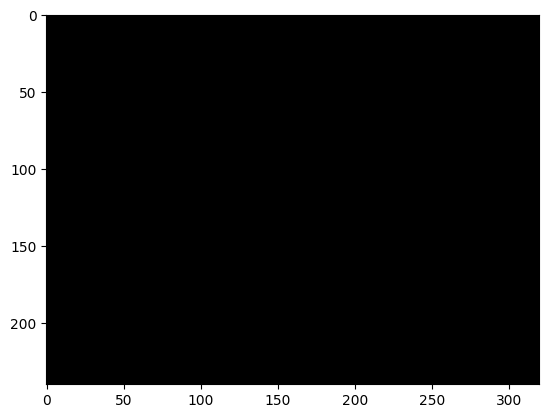

In [145]:
sorted_keys = natsorted(list(map1.keys()))
frame_num = 0

key = sorted_keys[frame_num]

frame_pts3d_old = map1[key]
frame_pts3d_new = map2[key]

print(frame_pts3d_old.shape, frame_pts3d_old.dtype)
print(frame_pts3d_new.shape, frame_pts3d_new.dtype)

diff = np.abs(frame_pts3d_old - frame_pts3d_new)
print(f"{diff.min() = } | {diff.max() = } | {diff.mean() = }")

plt.imshow(diff * 1000)
plt.show()

# plt.imshow(frame_pts3d_new)
# plt.show()

In [80]:
# Test if torch.no_grad() causes the difference
import torch

# Check if the old npz contains tensors or numpy arrays
key = sorted_keys[0]
old_data = pts3d_old[list(pts3d_old.keys())[0]]
new_data = pts3d_new[list(pts3d_new.keys())[0]]

print(f"Old data type: {type(old_data)}")
print(f"New data type: {type(new_data)}")
print(f"Old dtype: {old_data.dtype}")
print(f"New dtype: {new_data.dtype}")

Old data type: <class 'numpy.ndarray'>
New data type: <class 'numpy.ndarray'>
Old dtype: float32
New dtype: float32


In [81]:
def verify_point_clouds_robust(file_path1, file_path2):
    """
    Verify if two point cloud .npz files contain the same data, 
    matching arrays by their filename (ignoring parent directories).
    Iterates in natural sorted order.
    """
    print(f"Comparing:")
    print(f"  Old: {file_path1}")
    print(f"  New: {file_path2}")
    
    # Load files
    try:
        data1 = np.load(file_path1, allow_pickle=True)
        data2 = np.load(file_path2, allow_pickle=True)
    except Exception as e:
        print(f"Error loading files: {e}")
        return False
    # Create mapping from basename -> original_key -> data
    def get_basename_map(data_obj):
        mapping = {}
        for key in data_obj.files:
            # Extract just the filename (e.g., "00000.jpg" from "/path/to/00000.jpg")
            basename = os.path.basename(key)
            mapping[basename] = data_obj[key]
        return mapping
    map1 = get_basename_map(data1)
    map2 = get_basename_map(data2)
    
    keys1 = set(map1.keys())
    keys2 = set(map2.keys())
    
    # 1. Compare Keys (Basenames)
    if keys1 != keys2:
        print(f"❌ Key mismatch (by basename)!")
        print(f"  In file 1 only: {len(keys1 - keys2)}")
        print(f"  In file 2 only: {len(keys2 - keys1)}")
        return False
    else:
        print(f"✅ Keys match ({len(keys1)} images)")
    # 2. Compare Data
    all_match = True
    mismatches = []
    
    # Sort keys for deterministic, natural order
    sorted_keys = natsorted(list(keys1))
    
    for basename in sorted_keys:
        arr1 = map1[basename]
        arr2 = map2[basename]
        
        # Check shape
        if arr1.shape != arr2.shape:
            print(f"  ❌ Shape mismatch for {basename}: {arr1.shape} vs {arr2.shape}")
            all_match = False
            continue
            
        # Check values
        if not np.allclose(arr1, arr2, rtol=1e-5, atol=1e-8):
            diff = np.abs(arr1 - arr2)
            max_diff = np.max(diff)
            print(f"  ❌ Value mismatch for {basename} (Max diff: {max_diff})")
            mismatches.append(basename)
            all_match = False
    
    if all_match:
        print(f"\n✅ SUCCESS: All {len(keys1)} point clouds are identical!")
        return True
    else:
        print(f"\n❌ FAILED: Found mismatches in {len(mismatches)} files.")
        return False

In [82]:
verify_point_clouds_robust(PTS3D_FILE_OLD, PTS3D_FILE_NEW)

Comparing:
  Old: /scratch2/public_scratch/vanshg/mast3r-nav/hm3d_sg_habitat_mapping_replicate/svBbv1Pavdk_0000000_plant_7_/nodes_mast3r_points.npz
  New: /scratch2/public_scratch/vanshg/mast3r-nav/hm3d_val_mapping_pairwise_match_subsample/svBbv1Pavdk_0000000_plant_7_/nodes_mast3r_points.npz
✅ Keys match (33 images)

✅ SUCCESS: All 33 point clouds are identical!


True

## Verifying costmaps


In [4]:
# Costmap file paths
COSTMAP_FILE_NAME_OLD = "costmaps_320x240_EC_NONE_NC_NONE_NCF_10.npz"
COSTMAP_FILE_NAME_NEW = "costmaps_320x240_EC_NONE_NC_NONE_NCF_10.npz"

COSTMAP_FILE_OLD = SCENE_DIR_OLD / COSTMAP_FILE_NAME_OLD
COSTMAP_FILE_NEW = SCENE_DIR_NEW / COSTMAP_FILE_NAME_NEW

print(f"{COSTMAP_FILE_OLD = }")
print(f"{COSTMAP_FILE_NEW = }")
print(f"Old exists: {COSTMAP_FILE_OLD.exists()}")
print(f"New exists: {COSTMAP_FILE_NEW.exists()}")

COSTMAP_FILE_OLD = PosixPath('/scratch2/public_scratch/vanshg/mast3r-nav/hm3d_val_mapping_04ed325_commit_sg_habitat/mL8ThkuaVTM_0000000_bed_26_/costmaps_320x240_EC_NONE_NC_NONE_NCF_10.npz')
COSTMAP_FILE_NEW = PosixPath('/scratch2/public_scratch/vanshg/mast3r-nav/hm3d_val_mapping_pairwise_match_subsample_v2/mL8ThkuaVTM_0000000_bed_26_/costmaps_320x240_EC_NONE_NC_NONE_NCF_10.npz')
Old exists: True
New exists: True


In [5]:
def load_costmap_data(filepath):
    """Load costmap npz file and return costmaps array and metadata."""
    data = np.load(filepath, allow_pickle=True)
    costmaps = data['costmaps']
    metadata = json.loads(data['metadata'].item())
    return costmaps, metadata

costmaps_old, metadata_old = load_costmap_data(COSTMAP_FILE_OLD)
costmaps_new, metadata_new = load_costmap_data(COSTMAP_FILE_NEW)

print(f"Old costmaps shape: {costmaps_old.shape}, dtype: {costmaps_old.dtype}")
print(f"New costmaps shape: {costmaps_new.shape}, dtype: {costmaps_new.dtype}")

Old costmaps shape: (26, 240, 320), dtype: float32
New costmaps shape: (26, 240, 320), dtype: float64


In [6]:
# Compare metadata
print("=" * 60)
print("METADATA COMPARISON")
print("=" * 60)

print("\nOld metadata keys:", list(metadata_old.keys()))
print("New metadata keys:", list(metadata_new.keys()))

# Compare specific fields
for key in ['goal_img_idx', 'goal_pixel', 'goal_node_id', 'shape']:
    old_val = metadata_old.get(key)
    new_val = metadata_new.get(key)
    match = old_val == new_val
    status = "✅" if match else "❌"
    print(f"{status} {key}: old={old_val}, new={new_val}")

METADATA COMPARISON

Old metadata keys: ['goal_img_idx', 'goal_pixel', 'goal_node_id', 'shape', 'num_images', 'height', 'width', 'image_paths', 'goal_coord_3d']
New metadata keys: ['goal_img_idx', 'goal_pixel', 'goal_node_id', 'cfg', 'goal_coord_3d', 'image_paths', 'shape']
✅ goal_img_idx: old=25, new=25
✅ goal_pixel: old=[176, 138], new=[176, 138]
✅ goal_node_id: old=1964336, new=1964336
✅ shape: old=[26, 240, 320], new=[26, 240, 320]


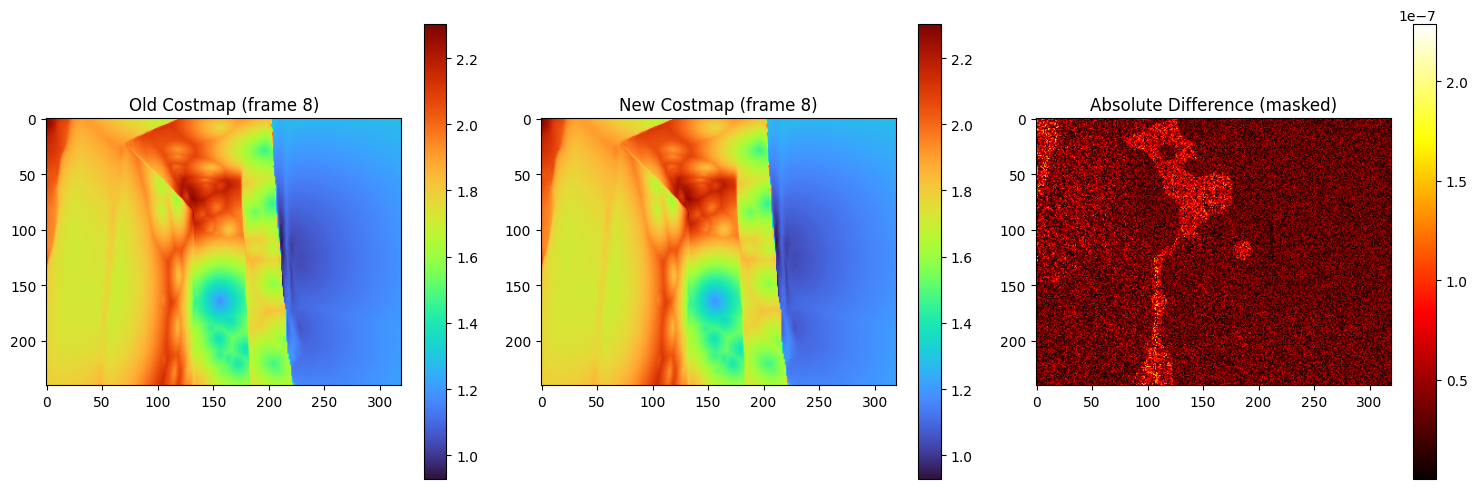

Diff stats (all): min=0.000000, max=0.000000, mean=0.000000
Diff stats (masked): min=0.000000, max=0.000000, mean=0.000000


In [ ]:
# Visualize a single frame comparison
# frame_idx = metadata_old.get('goal_img_idx', 0)  # Use goal image for comparison
frame_idx = 8
# frame_idx = 0

costmap_frame_old = costmaps_old[frame_idx]
costmap_frame_new = costmaps_new[frame_idx]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Old costmap
im0 = axes[0].imshow(costmap_frame_old, cmap='turbo')
axes[0].set_title(f'Old Costmap (frame {frame_idx})')
plt.colorbar(im0, ax=axes[0])

# New costmap
im1 = axes[1].imshow(costmap_frame_new, cmap='turbo')
axes[1].set_title(f'New Costmap (frame {frame_idx})')
plt.colorbar(im1, ax=axes[1])

# Difference
diff = np.abs(costmap_frame_old - costmap_frame_new)
# Mask out max values (1e6) for better visualization
diff_masked = np.where((costmap_frame_old < 1e5) & (costmap_frame_new < 1e5), diff, 0)
im2 = axes[2].imshow(diff_masked, cmap='hot')
axes[2].set_title(f'Absolute Difference (masked)')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

print(f"Diff stats (all): min={diff.min()}, max={diff.max()}, mean={diff.mean()}")
print(f"Diff stats (masked): min={diff_masked.min()}, max={diff_masked.max()}, mean={diff_masked.mean()}")

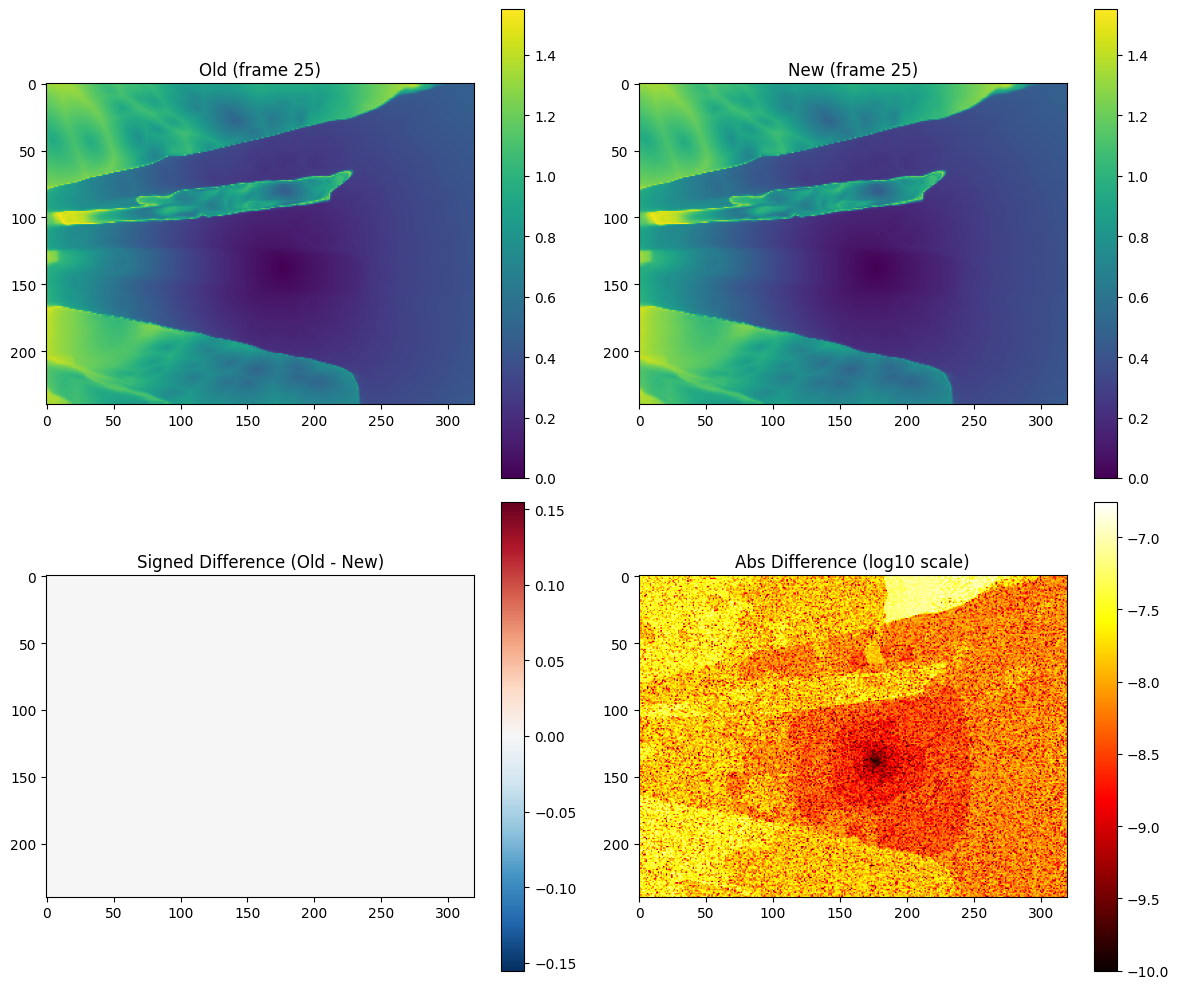

Frame 25 stats (valid pixels only):
  Num valid: 76800
  Diff min/max/mean: 0.000000 / 0.000000 / 0.000000


In [169]:
# Optional: Detailed per-frame visualization of differences
def plot_frame_comparison(costmaps_old, costmaps_new, frame_idx, vmax=None):
    """Plot detailed comparison for a specific frame."""
    c_old = costmaps_old[frame_idx]
    c_new = costmaps_new[frame_idx]
    
    # Clip for visualization (ignore 1e6 values)
    if vmax is None:
        valid_old = c_old[c_old < 1e5]
        valid_new = c_new[c_new < 1e5]
        vmax = max(valid_old.max() if len(valid_old) > 0 else 0,
                   valid_new.max() if len(valid_new) > 0 else 0)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Old
    im0 = axes[0, 0].imshow(np.clip(c_old, 0, vmax), cmap='viridis', vmax=vmax)
    axes[0, 0].set_title(f'Old (frame {frame_idx})')
    plt.colorbar(im0, ax=axes[0, 0])
    
    # New
    im1 = axes[0, 1].imshow(np.clip(c_new, 0, vmax), cmap='viridis', vmax=vmax)
    axes[0, 1].set_title(f'New (frame {frame_idx})')
    plt.colorbar(im1, ax=axes[0, 1])
    
    # Difference
    diff = c_old - c_new  # Signed difference
    diff_clipped = np.clip(diff, -vmax/10, vmax/10)
    im2 = axes[1, 0].imshow(diff_clipped, cmap='RdBu_r', vmin=-vmax/10, vmax=vmax/10)
    axes[1, 0].set_title('Signed Difference (Old - New)')
    plt.colorbar(im2, ax=axes[1, 0])
    
    # Absolute difference (log scale for better visibility)
    abs_diff = np.abs(diff)
    abs_diff_log = np.log10(abs_diff + 1e-10)
    im3 = axes[1, 1].imshow(abs_diff_log, cmap='hot')
    axes[1, 1].set_title('Abs Difference (log10 scale)')
    plt.colorbar(im3, ax=axes[1, 1])
    
    plt.tight_layout()
    plt.show()
    
    # Print stats
    valid_mask = (c_old < 1e5) & (c_new < 1e5)
    if valid_mask.sum() > 0:
        valid_diff = abs_diff[valid_mask]
        print(f"Frame {frame_idx} stats (valid pixels only):")
        print(f"  Num valid: {valid_mask.sum()}")
        print(f"  Diff min/max/mean: {valid_diff.min():.6f} / {valid_diff.max():.6f} / {valid_diff.mean():.6f}")

# Plot goal frame
plot_frame_comparison(costmaps_old, costmaps_new, metadata_old.get('goal_img_idx', 0))

## Random Debugging by Claude

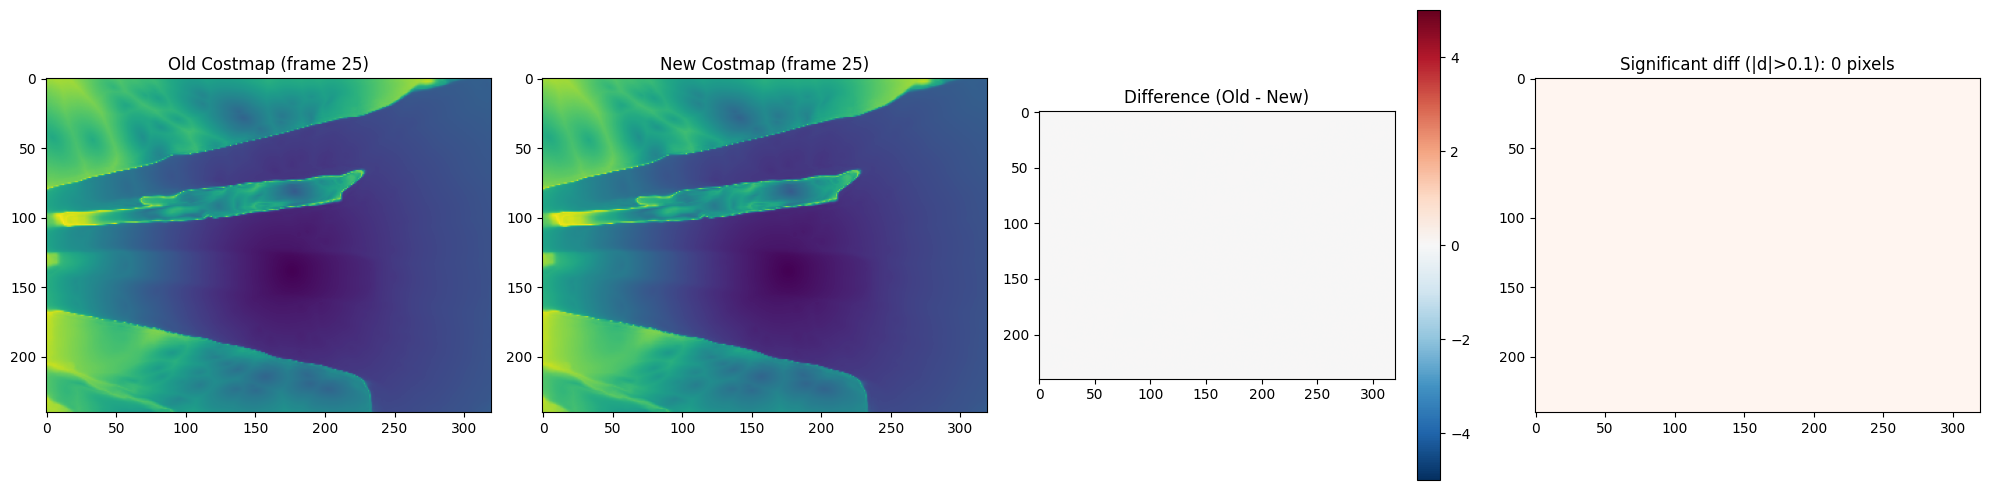

Valid pixels: 76,800
Diff stats: mean=0.0000, std=0.0000, max=0.0000
Pixels with diff > 0.1: 0
Pixels with diff > 1.0: 0
Pixels with diff > 5.0: 0


In [170]:
def visualize_difference_pattern_fixed(costmaps_old, costmaps_new, frame_idx=0):
    """Visualize difference pattern (without transpose comparison since shapes differ)."""
    
    c_old = costmaps_old[frame_idx]
    c_new = costmaps_new[frame_idx]
    
    # Clip for visualization
    vmax = 50
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    # Old costmap
    axes[0].imshow(np.clip(c_old, 0, vmax), cmap='viridis')
    axes[0].set_title(f'Old Costmap (frame {frame_idx})')
    
    # New costmap
    axes[1].imshow(np.clip(c_new, 0, vmax), cmap='viridis')
    axes[1].set_title(f'New Costmap (frame {frame_idx})')
    
    # Difference
    diff = c_old - c_new
    diff_clipped = np.clip(diff, -5, 5)
    im = axes[2].imshow(diff_clipped, cmap='RdBu_r', vmin=-5, vmax=5)
    axes[2].set_title('Difference (Old - New)')
    plt.colorbar(im, ax=axes[2])
    
    # Binary mask: where differences are significant
    significant_diff = np.abs(diff) > 0.1
    axes[3].imshow(significant_diff, cmap='Reds')
    axes[3].set_title(f'Significant diff (|d|>0.1): {significant_diff.sum()} pixels')
    
    plt.tight_layout()
    plt.show()
    
    # Statistics
    valid = (c_old < 1e5) & (c_new < 1e5)
    if valid.sum() > 0:
        valid_diff = np.abs(diff[valid])
        print(f"Valid pixels: {valid.sum():,}")
        print(f"Diff stats: mean={valid_diff.mean():.4f}, std={valid_diff.std():.4f}, max={valid_diff.max():.4f}")
        print(f"Pixels with diff > 0.1: {(valid_diff > 0.1).sum()}")
        print(f"Pixels with diff > 1.0: {(valid_diff > 1.0).sum()}")
        print(f"Pixels with diff > 5.0: {(valid_diff > 5.0).sum()}")

# Run the fixed visualization
visualize_difference_pattern_fixed(costmaps_old, costmaps_new, frame_idx=metadata_old.get('goal_img_idx', 0))

DIFFERENCE SOURCE ANALYSIS

Per-frame mean absolute error:
  Min frame error: 0.000000 (frame 25)
  Max frame error: 0.000000 (frame 0)
  Mean frame error: 0.000000


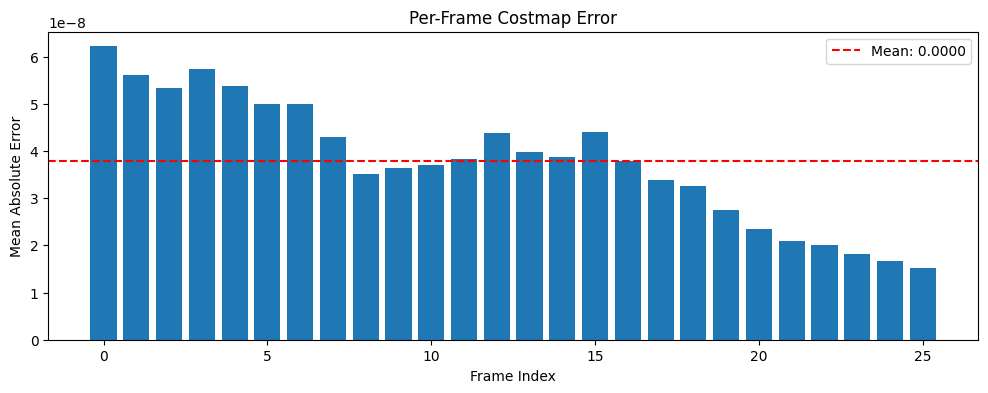


Correlation between frame distance from goal and error: 0.9455


In [171]:
# Cell: Analyze the spatial pattern of differences

def analyze_difference_sources(costmaps_old, costmaps_new):
    """Analyze where differences come from."""
    
    print("=" * 60)
    print("DIFFERENCE SOURCE ANALYSIS")
    print("=" * 60)
    
    N, H, W = costmaps_old.shape
    
    # Per-frame analysis
    frame_errors = []
    for i in range(N):
        valid = (costmaps_old[i] < 1e5) & (costmaps_new[i] < 1e5)
        if valid.sum() > 0:
            err = np.abs(costmaps_old[i][valid] - costmaps_new[i][valid]).mean()
            frame_errors.append(err)
        else:
            frame_errors.append(np.nan)
    
    frame_errors = np.array(frame_errors)
    
    print(f"\nPer-frame mean absolute error:")
    print(f"  Min frame error: {np.nanmin(frame_errors):.6f} (frame {np.nanargmin(frame_errors)})")
    print(f"  Max frame error: {np.nanmax(frame_errors):.6f} (frame {np.nanargmax(frame_errors)})")
    print(f"  Mean frame error: {np.nanmean(frame_errors):.6f}")
    
    # Plot frame errors
    plt.figure(figsize=(12, 4))
    plt.bar(range(N), frame_errors)
    plt.xlabel('Frame Index')
    plt.ylabel('Mean Absolute Error')
    plt.title('Per-Frame Costmap Error')
    plt.axhline(y=np.nanmean(frame_errors), color='r', linestyle='--', label=f'Mean: {np.nanmean(frame_errors):.4f}')
    plt.legend()
    plt.show()
    
    # Check if error correlates with distance from goal
    goal_idx = metadata_old.get('goal_img_idx', N-1)
    distances_from_goal = np.abs(np.arange(N) - goal_idx)
    
    valid_frames = ~np.isnan(frame_errors)
    if valid_frames.sum() > 2:
        correlation = np.corrcoef(distances_from_goal[valid_frames], frame_errors[valid_frames])[0, 1]
        print(f"\nCorrelation between frame distance from goal and error: {correlation:.4f}")
    
    return frame_errors

frame_errors = analyze_difference_sources(costmaps_old, costmaps_new)

## Verifying the graphs directly

In [148]:
# =============================================================================
# GRAPH COMPARISON: OLD (Dense) vs NEW (Sparse)
# =============================================================================

import pickle
import blosc2
import networkx as nx

# Graph file paths
GRAPH_FILE_NAME_OLD = "graph_with_distances_to_goalnode_fixed.pkl.b2s"
GRAPH_FILE_NAME_NEW = "graph_with_distances_to_goal_320x240_EC_NONE_NC_NONE_NCF_10.pkl.b2s"

GRAPH_FILE_OLD = SCENE_DIR_OLD / GRAPH_FILE_NAME_OLD
GRAPH_FILE_NEW = SCENE_DIR_NEW / GRAPH_FILE_NAME_NEW

print(f"{GRAPH_FILE_OLD = }")
print(f"{GRAPH_FILE_NEW = }")
print(f"Old exists: {GRAPH_FILE_OLD.exists()}")
print(f"New exists: {GRAPH_FILE_NEW.exists()}")

GRAPH_FILE_OLD = PosixPath('/scratch2/public_scratch/vanshg/sg_habitat/hm3d_val_mapping_04ed325_commit/4ok3usBNeis_0000000_chair_8_/graph_with_distances_to_goalnode_fixed.pkl.b2s')
GRAPH_FILE_NEW = PosixPath('/scratch2/public_scratch/vanshg/mast3r-nav/hm3d_val_mapping_pairwise_match_subsample_v2/4ok3usBNeis_0000000_chair_8_/graph_with_distances_to_goal_320x240_EC_NONE_NC_NONE_NCF_10.pkl.b2s')
Old exists: True
New exists: True


In [149]:
# Load functions for both graph formats

def load_old_graph_chunked(compressed_path):
    """Load old graph format (from map_topo_3d_points.py)"""
    print(f"Loading OLD graph from: {compressed_path}")
    
    with open(compressed_path, 'rb') as f:
        format_marker = f.read(6)
        
        if format_marker == b"SINGLE":
            compressed_size = int.from_bytes(f.read(8), 'little')
            compressed_data = f.read(compressed_size)
            decompressed = blosc2.decompress(compressed_data)
            graph_data = pickle.loads(decompressed)
            
        elif format_marker == b"CHUNKS":
            num_chunks = int.from_bytes(f.read(4), 'little')
            original_size = int.from_bytes(f.read(8), 'little')
            
            chunk_sizes = []
            for _ in range(num_chunks):
                chunk_size = int.from_bytes(f.read(4), 'little')
                chunk_sizes.append(chunk_size)
            
            decompressed_chunks = []
            for i, chunk_size in enumerate(chunk_sizes):
                compressed_chunk = f.read(chunk_size)
                decompressed_chunk = blosc2.decompress(compressed_chunk)
                decompressed_chunks.append(decompressed_chunk)
            
            decompressed = b''.join(decompressed_chunks)
            graph_data = pickle.loads(decompressed)
        else:
            raise ValueError(f"Unknown format marker: {format_marker}")
    
    # Reconstruct NetworkX graph
    G = nx.Graph()
    
    # Reconstruct nodes - OLD format uses 'coord_mast3r' and 'weight_mast3r'
    node_ids = graph_data['node_ids']
    node_maps = graph_data['node_maps']
    node_coords = graph_data['node_coords']
    node_pixels = graph_data['node_pixels']
    node_types = graph_data['node_types']
    
    for i, node_id in enumerate(node_ids):
        attrs = {
            'map': node_maps[i].tolist(),
            'coord_mast3r': node_coords[i],
            'pixel': node_pixels[i].tolist(),
            'type': str(node_types[i])
        }
        G.add_node(node_id, **attrs)
    
    # Reconstruct edges - OLD format uses 'edgeType' and 'weight_mast3r'
    edge_sources = graph_data['edge_sources']
    edge_targets = graph_data['edge_targets']
    edge_margins = graph_data.get('edge_margins', np.ones(len(edge_sources)))
    edge_types = graph_data['edge_types']
    edge_weights = graph_data['edge_weights']
    
    for i in range(len(edge_sources)):
        attrs = {
            'margin': float(edge_margins[i]) if i < len(edge_margins) else 1.0,
            'edgeType': str(edge_types[i]),
            'weight_mast3r': float(edge_weights[i])
        }
        G.add_edge(edge_sources[i], edge_targets[i], **attrs)
    
    # Reconstruct graph attributes
    G.graph.update(graph_data['graph_attrs'])
    
    # Reconstruct allPathLengths - OLD format uses 'weight_mast3r' key
    if 'path_nodes' in graph_data and 'path_distances' in graph_data:
        path_nodes = graph_data['path_nodes']
        path_distances = graph_data['path_distances']
        path_dict = dict(zip(path_nodes, path_distances))
        G.graph['allPathLengths'] = {'weight_mast3r': path_dict}
    
    print(f"Loaded OLD graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    return G


def load_new_graph_chunked(compressed_path):
    """Load new graph format (from create_topomap.py)"""
    print(f"Loading NEW graph from: {compressed_path}")
    
    with open(compressed_path, 'rb') as f:
        format_marker = f.read(6)
        
        if format_marker == b"SINGLE":
            compressed_size = int.from_bytes(f.read(8), 'little')
            compressed_data = f.read(compressed_size)
            decompressed = blosc2.decompress(compressed_data)
            graph_data = pickle.loads(decompressed)
            
        elif format_marker == b"CHUNKS":
            num_chunks = int.from_bytes(f.read(4), 'little')
            original_size = int.from_bytes(f.read(8), 'little')
            
            chunk_sizes = []
            for _ in range(num_chunks):
                chunk_size = int.from_bytes(f.read(4), 'little')
                chunk_sizes.append(chunk_size)
            
            decompressed_chunks = []
            for i, chunk_size in enumerate(chunk_sizes):
                compressed_chunk = f.read(chunk_size)
                decompressed_chunk = blosc2.decompress(compressed_chunk)
                decompressed_chunks.append(decompressed_chunk)
            
            decompressed = b''.join(decompressed_chunks)
            graph_data = pickle.loads(decompressed)
        else:
            raise ValueError(f"Unknown format marker: {format_marker}")
    
    # Reconstruct NetworkX graph
    G = nx.Graph()
    
    # Reconstruct nodes - NEW format uses 'coord_mast3r' and 'weight'
    node_ids = graph_data['node_ids']
    node_maps = graph_data['node_maps']
    node_coords = graph_data['node_coords']
    node_pixels = graph_data['node_pixels']
    node_types = graph_data['node_types']
    
    for i, node_id in enumerate(node_ids):
        attrs = {
            'map': node_maps[i].tolist(),
            'coord_mast3r': node_coords[i],
            'pixel': node_pixels[i].tolist(),
            'type': str(node_types[i])
        }
        G.add_node(node_id, **attrs)
    
    # Reconstruct edges - NEW format uses 'edge_type' and 'weight'
    edge_sources = graph_data['edge_sources']
    edge_targets = graph_data['edge_targets']
    edge_types = graph_data['edge_types']
    edge_weights = graph_data['edge_weights']
    
    for i in range(len(edge_sources)):
        attrs = {
            'edge_type': str(edge_types[i]),
            'weight': float(edge_weights[i])
        }
        G.add_edge(edge_sources[i], edge_targets[i], **attrs)
    
    # Reconstruct graph attributes
    G.graph.update(graph_data['graph_attrs'])
    
    # Reconstruct all_path_lengths - NEW format uses 'weight' key
    if 'path_nodes' in graph_data and 'path_distances' in graph_data:
        path_nodes = graph_data['path_nodes']
        path_distances = graph_data['path_distances']
        path_dict = dict(zip(path_nodes, path_distances))
        G.graph['all_path_lengths'] = {'weight': path_dict}
    
    print(f"Loaded NEW graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    return G

In [150]:
# Load both graphs
G_old = load_old_graph_chunked(GRAPH_FILE_OLD)
G_new = load_new_graph_chunked(GRAPH_FILE_NEW)

Loading OLD graph from: /scratch2/public_scratch/vanshg/sg_habitat/hm3d_val_mapping_04ed325_commit/4ok3usBNeis_0000000_chair_8_/graph_with_distances_to_goalnode_fixed.pkl.b2s
Loaded OLD graph: 4761600 nodes, 3267711 edges
Loading NEW graph from: /scratch2/public_scratch/vanshg/mast3r-nav/hm3d_val_mapping_pairwise_match_subsample_v2/4ok3usBNeis_0000000_chair_8_/graph_with_distances_to_goal_320x240_EC_NONE_NC_NONE_NCF_10.pkl.b2s
Loaded NEW graph: 19471 nodes, 3267711 edges


In [151]:
# =============================================================================
# BASIC GRAPH COMPARISON
# =============================================================================

def compare_graph_basics(G_old, G_new):
    """Compare basic graph statistics"""
    print("=" * 60)
    print("BASIC GRAPH COMPARISON")
    print("=" * 60)
    
    print(f"\n{'Metric':<30} {'OLD':<20} {'NEW':<20}")
    print("-" * 70)
    print(f"{'Total nodes':<30} {G_old.number_of_nodes():<20,} {G_new.number_of_nodes():<20,}")
    print(f"{'Total edges':<30} {G_old.number_of_edges():<20,} {G_new.number_of_edges():<20,}")
    
    # Count node types
    old_types = {}
    for _, data in G_old.nodes(data=True):
        t = data.get('type', 'unknown')
        old_types[t] = old_types.get(t, 0) + 1
    
    new_types = {}
    for _, data in G_new.nodes(data=True):
        t = data.get('type', 'unknown')
        new_types[t] = new_types.get(t, 0) + 1
    
    print(f"\n{'Node type counts:':<30}")
    all_types = set(old_types.keys()) | set(new_types.keys())
    for t in sorted(all_types):
        print(f"  {t:<28} {old_types.get(t, 0):<20,} {new_types.get(t, 0):<20,}")
    
    # Count edge types
    old_edge_types = {}
    for _, _, data in G_old.edges(data=True):
        t = data.get('edgeType', data.get('edge_type', 'unknown'))
        old_edge_types[t] = old_edge_types.get(t, 0) + 1
    
    new_edge_types = {}
    for _, _, data in G_new.edges(data=True):
        t = data.get('edge_type', data.get('edgeType', 'unknown'))
        new_edge_types[t] = new_edge_types.get(t, 0) + 1
    
    print(f"\n{'Edge type counts:':<30}")
    all_edge_types = set(old_edge_types.keys()) | set(new_edge_types.keys())
    for t in sorted(all_edge_types):
        print(f"  {t:<28} {old_edge_types.get(t, 0):<20,} {new_edge_types.get(t, 0):<20,}")

compare_graph_basics(G_old, G_new)

BASIC GRAPH COMPARISON

Metric                         OLD                  NEW                 
----------------------------------------------------------------------
Total nodes                    4,761,600            19,471              
Total edges                    3,267,711            3,267,711           

Node type counts:             
  base                         4,694,875            0                   
  da                           19,470               19,470              
  goal                         1                    1                   
  selected                     47,254               0                   

Edge type counts:             
  da                           10,028               10,028              
  da_intra                     3,257,444            3,257,444           
  goal_da_in                   239                  239                 


In [152]:
# =============================================================================
# GOAL NODE COMPARISON
# =============================================================================

def compare_goal_info(G_old, G_new):
    """Compare goal node information between old and new graphs"""
    print("=" * 60)
    print("GOAL NODE COMPARISON")
    print("=" * 60)
    
    # OLD graph attributes (camelCase)
    old_goal_img_idx = G_old.graph.get('goalImgIdx')
    old_goal_coords = G_old.graph.get('goalNodeCoords')
    old_goal_node_id = G_old.graph.get('goalNodeId')
    
    # NEW graph attributes (snake_case)
    new_goal_img_idx = G_new.graph.get('goal_img_idx')
    new_goal_coords = G_new.graph.get('goal_node_coords')
    new_goal_node_id = G_new.graph.get('goal_node_id')
    
    print(f"\n{'Attribute':<25} {'OLD':<25} {'NEW':<25} {'Match':<10}")
    print("-" * 85)
    
    # Goal image index
    match = old_goal_img_idx == new_goal_img_idx
    print(f"{'Goal image index':<25} {str(old_goal_img_idx):<25} {str(new_goal_img_idx):<25} {'✅' if match else '❌'}")
    
    # Goal coordinates
    match = old_goal_coords == new_goal_coords
    print(f"{'Goal pixel coords':<25} {str(old_goal_coords):<25} {str(new_goal_coords):<25} {'✅' if match else '❌'}")
    
    # Goal node ID
    match = old_goal_node_id == new_goal_node_id
    print(f"{'Goal node ID':<25} {str(old_goal_node_id):<25} {str(new_goal_node_id):<25} {'✅' if match else '❌'}")
    
    # Check if goal nodes exist in graphs
    old_goal_exists = old_goal_node_id in G_old.nodes if old_goal_node_id else False
    new_goal_exists = new_goal_node_id in G_new.nodes if new_goal_node_id else False
    print(f"{'Goal node in graph':<25} {str(old_goal_exists):<25} {str(new_goal_exists):<25}")
    
    # Compare goal node attributes if both exist
    if old_goal_exists and new_goal_exists:
        old_goal_node = G_old.nodes[old_goal_node_id]
        new_goal_node = G_new.nodes[new_goal_node_id]
        
        print(f"\n--- Goal Node Attributes ---")
        print(f"{'Attribute':<25} {'OLD':<35} {'NEW':<35}")
        print("-" * 95)
        
        # Pixel
        old_pixel = old_goal_node.get('pixel')
        new_pixel = new_goal_node.get('pixel')
        match = old_pixel == new_pixel
        print(f"{'pixel':<25} {str(old_pixel):<35} {str(new_pixel):<35} {'✅' if match else '❌'}")
        
        # Type
        old_type = old_goal_node.get('type')
        new_type = new_goal_node.get('type')
        match = old_type == new_type
        print(f"{'type':<25} {str(old_type):<35} {str(new_type):<35} {'✅' if match else '❌'}")
        
        # 3D coordinate
        old_coord = old_goal_node.get('coord_mast3r')
        new_coord = new_goal_node.get('coord_mast3r')
        if old_coord is not None and new_coord is not None:
            coord_diff = np.linalg.norm(old_coord - new_coord)
            match = coord_diff < 1e-6
            print(f"{'coord_mast3r diff':<25} {coord_diff:<35.8f} {'✅' if match else '❌'}")
    
    return old_goal_node_id, new_goal_node_id

old_goal_id, new_goal_id = compare_goal_info(G_old, G_new)

GOAL NODE COMPARISON

Attribute                 OLD                       NEW                       Match     
-------------------------------------------------------------------------------------
Goal image index          61                        61                        ✅
Goal pixel coords         (157, 192)                (157, 192)                ✅
Goal node ID              4746397                   4746397                   ✅
Goal node in graph        True                      True                     

--- Goal Node Attributes ---
Attribute                 OLD                                 NEW                                
-----------------------------------------------------------------------------------------------
pixel                     [192, 157]                          [157, 192]                          ❌
type                      goal                                goal                                ✅
coord_mast3r diff         0.00000000                         

In [153]:
# =============================================================================
# DA NODE COMPARISON (Per Image)
# =============================================================================

def extract_da_nodes_by_image(G, is_old_format=True):
    """Extract DA nodes grouped by image index"""
    da_nodes_per_img = {}
    
    for node_id, data in G.nodes(data=True):
        node_type = data.get('type', '')
        if node_type in ['da', 'goal']:
            img_idx = data['map'][0]
            pixel = tuple(data['pixel'])  # (px, py) or (py, px)?
            coord = data.get('coord_mast3r')
            
            if img_idx not in da_nodes_per_img:
                da_nodes_per_img[img_idx] = {}
            
            da_nodes_per_img[img_idx][node_id] = {
                'pixel': pixel,
                'coord_mast3r': coord,
                'type': node_type
            }
    
    return da_nodes_per_img


def compare_da_nodes_per_image(G_old, G_new, H=240, W=320):
    """Compare DA nodes between old and new graphs per image"""
    print("=" * 60)
    print("DA NODE COMPARISON (Per Image)")
    print("=" * 60)
    
    old_da = extract_da_nodes_by_image(G_old, is_old_format=True)
    new_da = extract_da_nodes_by_image(G_new, is_old_format=False)
    
    all_img_indices = set(old_da.keys()) | set(new_da.keys())
    print(f"\nTotal images with DA nodes: OLD={len(old_da)}, NEW={len(new_da)}")
    
    # Per-image comparison
    print(f"\n{'Img':<5} {'OLD DA':<10} {'NEW DA':<10} {'Common':<10} {'Old Only':<10} {'New Only':<10}")
    print("-" * 60)
    
    total_common = 0
    total_old_only = 0
    total_new_only = 0
    
    # Store common nodes for detailed comparison
    common_nodes_all = {}
    
    for img_idx in sorted(all_img_indices):
        old_nodes = old_da.get(img_idx, {})
        new_nodes = new_da.get(img_idx, {})
        
        # Extract pixel coordinates for comparison
        # OLD format stores pixel as [py, px] (row, col)
        # NEW format stores pixel as [px, py] (col, row)
        old_pixels = set()
        old_pixel_to_node = {}
        for nid, data in old_nodes.items():
            # OLD: pixel is [py, px], convert to (px, py) for comparison
            py, px = data['pixel']
            pixel_key = (px, py)
            old_pixels.add(pixel_key)
            old_pixel_to_node[pixel_key] = nid
        
        new_pixels = set()
        new_pixel_to_node = {}
        for nid, data in new_nodes.items():
            # NEW: pixel is [px, py]
            px, py = data['pixel']
            pixel_key = (px, py)
            new_pixels.add(pixel_key)
            new_pixel_to_node[pixel_key] = nid
        
        common = old_pixels & new_pixels
        old_only = old_pixels - new_pixels
        new_only = new_pixels - old_pixels
        
        total_common += len(common)
        total_old_only += len(old_only)
        total_new_only += len(new_only)
        
        # Store common nodes for coordinate comparison
        common_nodes_all[img_idx] = {
            'common_pixels': common,
            'old_pixel_to_node': old_pixel_to_node,
            'new_pixel_to_node': new_pixel_to_node,
            'old_nodes': old_nodes,
            'new_nodes': new_nodes
        }
        
        if len(old_nodes) > 0 or len(new_nodes) > 0:
            print(f"{img_idx:<5} {len(old_nodes):<10} {len(new_nodes):<10} {len(common):<10} {len(old_only):<10} {len(new_only):<10}")
    
    print("-" * 60)
    print(f"{'TOTAL':<5} {'':<10} {'':<10} {total_common:<10} {total_old_only:<10} {total_new_only:<10}")
    
    return common_nodes_all

common_nodes = compare_da_nodes_per_image(G_old, G_new)

DA NODE COMPARISON (Per Image)

Total images with DA nodes: OLD=62, NEW=62

Img   OLD DA     NEW DA     Common     Old Only   New Only  
------------------------------------------------------------
0     231        231        231        0          0         
1     301        301        301        0          0         
2     309        309        309        0          0         
3     352        352        352        0          0         
4     316        316        316        0          0         
5     289        289        289        0          0         
6     281        281        281        0          0         
7     251        251        251        0          0         
8     230        230        230        0          0         
9     221        221        221        0          0         
10    215        215        215        0          0         
11    221        221        221        0          0         
12    227        227        227        0          0         
13    299

MISSING NODE ANALYSIS

Total missing nodes: 4080
Total common nodes: 9084

Missing nodes spatial stats:
  px: min=3, max=316, mean=174.9
  py: min=3, max=236, mean=146.9

Common nodes spatial stats:
  px: min=3, max=316, mean=171.6
  py: min=3, max=236, mean=112.0

Missing nodes near border (within 3px): 0 / 4080


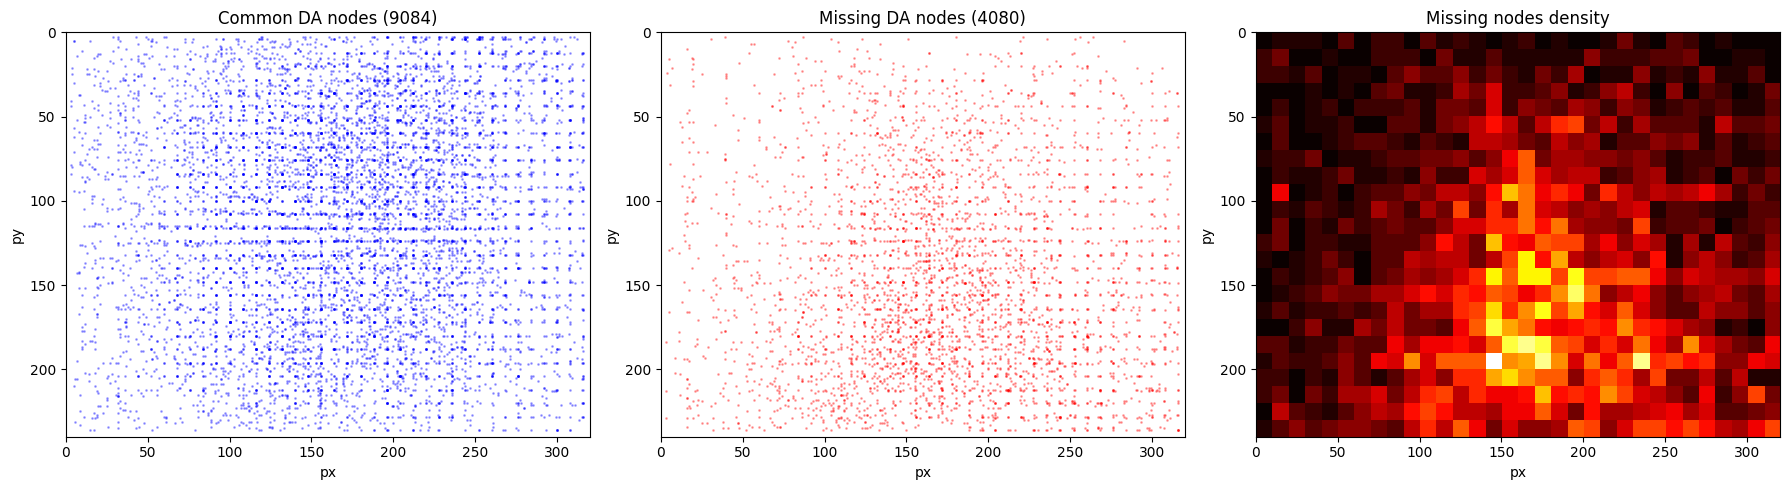

In [135]:
# =============================================================================
# INVESTIGATE MISSING DA NODES
# =============================================================================

def analyze_missing_nodes(common_nodes_all, G_old, H=240, W=320):
    """Analyze patterns in the missing DA nodes"""
    print("=" * 60)
    print("MISSING NODE ANALYSIS")
    print("=" * 60)
    
    missing_pixels_all = []
    common_pixels_all = []
    
    for img_idx, data in common_nodes_all.items():
        old_pixel_to_node = data['old_pixel_to_node']
        common_pixels = data['common_pixels']
        
        # Old-only pixels (missing in new)
        old_pixels = set(old_pixel_to_node.keys())
        missing = old_pixels - common_pixels
        
        for px, py in missing:
            missing_pixels_all.append({'img_idx': img_idx, 'px': px, 'py': py})
        for px, py in common_pixels:
            common_pixels_all.append({'img_idx': img_idx, 'px': px, 'py': py})
    
    missing_px = np.array([p['px'] for p in missing_pixels_all])
    missing_py = np.array([p['py'] for p in missing_pixels_all])
    common_px = np.array([p['px'] for p in common_pixels_all])
    common_py = np.array([p['py'] for p in common_pixels_all])
    
    print(f"\nTotal missing nodes: {len(missing_pixels_all)}")
    print(f"Total common nodes: {len(common_pixels_all)}")
    
    # Check spatial distribution
    print(f"\nMissing nodes spatial stats:")
    print(f"  px: min={missing_px.min()}, max={missing_px.max()}, mean={missing_px.mean():.1f}")
    print(f"  py: min={missing_py.min()}, max={missing_py.max()}, mean={missing_py.mean():.1f}")
    
    print(f"\nCommon nodes spatial stats:")
    print(f"  px: min={common_px.min()}, max={common_px.max()}, mean={common_px.mean():.1f}")
    print(f"  py: min={common_py.min()}, max={common_py.max()}, mean={common_py.mean():.1f}")
    
    # Check if missing nodes are near borders (could be border filtering)
    border = 3  # Common border value in fast_reciprocal_NNs
    near_border = ((missing_px < border) | (missing_px >= W - border) | 
                   (missing_py < border) | (missing_py >= H - border))
    print(f"\nMissing nodes near border (within {border}px): {near_border.sum()} / {len(missing_pixels_all)}")
    
    # Visualize spatial distribution
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Common nodes
    axes[0].scatter(common_px, common_py, s=1, alpha=0.3, c='blue')
    axes[0].set_xlim(0, W)
    axes[0].set_ylim(H, 0)  # Flip y-axis to match image coords
    axes[0].set_title(f'Common DA nodes ({len(common_pixels_all)})')
    axes[0].set_xlabel('px')
    axes[0].set_ylabel('py')
    
    # Missing nodes
    axes[1].scatter(missing_px, missing_py, s=1, alpha=0.3, c='red')
    axes[1].set_xlim(0, W)
    axes[1].set_ylim(H, 0)
    axes[1].set_title(f'Missing DA nodes ({len(missing_pixels_all)})')
    axes[1].set_xlabel('px')
    axes[1].set_ylabel('py')
    
    # 2D histogram of missing
    h, xedges, yedges = np.histogram2d(missing_px, missing_py, bins=[32, 24])
    axes[2].imshow(h.T, extent=[0, W, H, 0], aspect='auto', cmap='hot')
    axes[2].set_title('Missing nodes density')
    axes[2].set_xlabel('px')
    axes[2].set_ylabel('py')
    
    plt.tight_layout()
    plt.show()
    
    return missing_pixels_all

missing_nodes = analyze_missing_nodes(common_nodes, G_old)

In [136]:
# =============================================================================
# CHECK MATCH SUBSAMPLING PARAMETERS
# =============================================================================

def check_subsampling_hypothesis(common_nodes_all, G_old, G_new):
    """Check if the missing nodes follow a subsampling pattern"""
    print("=" * 60)
    print("SUBSAMPLING HYPOTHESIS CHECK")
    print("=" * 60)
    
    # The new code uses subsample=8 in fast_reciprocal_NNs
    # This means it keeps 1 out of every 8 matches
    # Let's check if the ratio matches
    
    total_old = 0
    total_new = 0
    
    for img_idx, data in common_nodes_all.items():
        old_nodes = data['old_pixel_to_node']
        new_nodes = data['new_pixel_to_node']
        total_old += len(old_nodes)
        total_new += len(new_nodes)
    
    ratio = total_old / total_new if total_new > 0 else 0
    print(f"\nOLD total DA nodes: {total_old}")
    print(f"NEW total DA nodes: {total_new}")
    print(f"Ratio (OLD/NEW): {ratio:.2f}")
    print(f"Expected ratio if subsample=8: ~1.0 (same images matched)")
    
    # Check if it's related to match pair filtering
    # The issue might be in how matches are selected from the subsample
    
    # Sample one image and check the pixel distribution
    sample_img = 0
    old_nodes = common_nodes_all[sample_img]['old_pixel_to_node']
    new_nodes = common_nodes_all[sample_img]['new_pixel_to_node']
    
    old_pixels = sorted(old_nodes.keys())
    new_pixels = sorted(new_nodes.keys())
    
    print(f"\nSample image {sample_img}:")
    print(f"  OLD DA nodes: {len(old_pixels)}")
    print(f"  NEW DA nodes: {len(new_pixels)}")
    
    # Check if new pixels are exactly a subset
    new_set = set(new_pixels)
    old_set = set(old_pixels)
    
    if new_set <= old_set:
        print(f"  ✅ NEW is exact subset of OLD")
    else:
        print(f"  ❌ NEW has pixels not in OLD: {len(new_set - old_set)}")

check_subsampling_hypothesis(common_nodes, G_old, G_new)

SUBSAMPLING HYPOTHESIS CHECK

OLD total DA nodes: 13164
NEW total DA nodes: 13123
Ratio (OLD/NEW): 1.00
Expected ratio if subsample=8: ~1.0 (same images matched)

Sample image 0:
  OLD DA nodes: 227
  NEW DA nodes: 227
  ❌ NEW has pixels not in OLD: 84


DA NODE ATTRIBUTE COMPARISON

Total OLD DA nodes: 13123
Total NEW DA nodes: 13123
Common pixels: 13123
Old only: 0
New only: 0

ATTRIBUTE MATCH SUMMARY

Attribute            Matches         Mismatches      Match Rate     
-----------------------------------------------------------------
Pixel (normalized)   13123           0               100.00%
Map                  13123           0               100.00%
Type                 13123           0               100.00%

coord_mast3r differences:
  Min:  0.00000000
  Max:  0.00000000
  Mean: 0.00000000
  Std:  0.00000000

  Nodes with coord diff > threshold:
    > 1e-08: 0 (0.00%)
    > 1e-06: 0 (0.00%)
    > 0.0001: 0 (0.00%)
    > 0.01: 0 (0.00%)
    > 0.1: 0 (0.00%)
    > 1.0: 0 (0.00%)


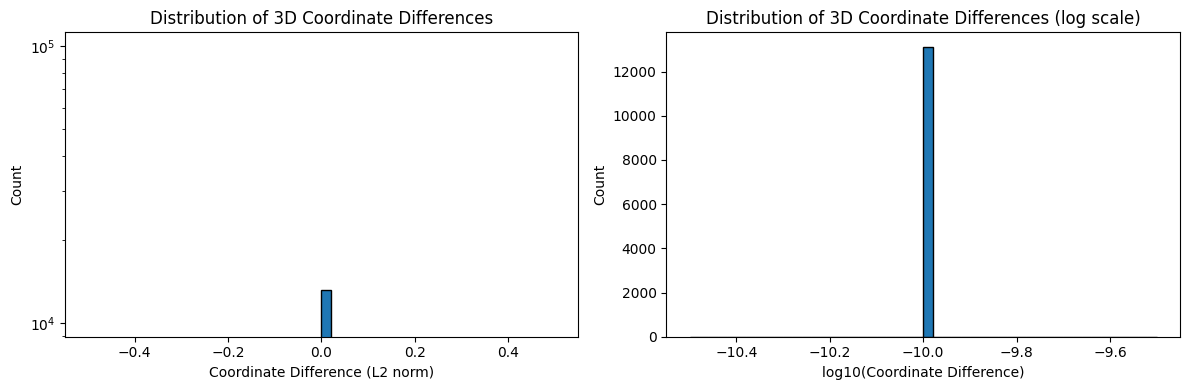

In [96]:
# =============================================================================
# COMPARE DA NODE ATTRIBUTES (Detailed)
# =============================================================================

def compare_da_node_attributes(G_old, G_new, H=240, W=320):
    """
    Compare attributes of DA nodes that exist in both graphs.
    Accounts for pixel format difference:
    - OLD: pixel = [py, px] (row, col)
    - NEW: pixel = [px, py] (col, row)
    """
    print("=" * 60)
    print("DA NODE ATTRIBUTE COMPARISON")
    print("=" * 60)
    
    # Extract DA nodes by image
    old_da = extract_da_nodes_by_image(G_old, is_old_format=True)
    new_da = extract_da_nodes_by_image(G_new, is_old_format=False)
    
    # Build mapping: (img_idx, px, py) -> node_id for both graphs
    # Normalize to (px, py) format for comparison
    old_pixel_to_node = {}  # (img_idx, px, py) -> node_id
    new_pixel_to_node = {}  # (img_idx, px, py) -> node_id
    
    for img_idx, nodes in old_da.items():
        for node_id, data in nodes.items():
            # OLD: pixel is [py, px]
            py, px = data['pixel']
            old_pixel_to_node[(img_idx, px, py)] = node_id
    
    for img_idx, nodes in new_da.items():
        for node_id, data in nodes.items():
            # NEW: pixel is [px, py]
            px, py = data['pixel']
            new_pixel_to_node[(img_idx, px, py)] = node_id
    
    # Find common pixels
    old_keys = set(old_pixel_to_node.keys())
    new_keys = set(new_pixel_to_node.keys())
    common_keys = old_keys & new_keys
    
    print(f"\nTotal OLD DA nodes: {len(old_keys)}")
    print(f"Total NEW DA nodes: {len(new_keys)}")
    print(f"Common pixels: {len(common_keys)}")
    print(f"Old only: {len(old_keys - new_keys)}")
    print(f"New only: {len(new_keys - old_keys)}")
    
    if len(common_keys) == 0:
        print("❌ No common nodes to compare!")
        return None
    
    # Compare attributes for common nodes
    coord_diffs = []
    pixel_mismatches = 0
    map_mismatches = 0
    type_mismatches = 0
    
    comparison_results = []
    
    for key in sorted(common_keys):
        img_idx, px, py = key
        old_node_id = old_pixel_to_node[key]
        new_node_id = new_pixel_to_node[key]
        
        old_attrs = G_old.nodes[old_node_id]
        new_attrs = G_new.nodes[new_node_id]
        
        result = {
            'img_idx': img_idx,
            'px': px,
            'py': py,
            'old_node_id': old_node_id,
            'new_node_id': new_node_id,
        }
        
        # Compare pixel (accounting for format difference)
        old_pixel = old_attrs.get('pixel', [])  # [py, px]
        new_pixel = new_attrs.get('pixel', [])  # [px, py]
        
        # Normalize both to (px, py)
        if len(old_pixel) == 2:
            old_pixel_normalized = (old_pixel[1], old_pixel[0])  # [py, px] -> (px, py)
        else:
            old_pixel_normalized = tuple(old_pixel)
            
        if len(new_pixel) == 2:
            new_pixel_normalized = (new_pixel[0], new_pixel[1])  # [px, py] -> (px, py)
        else:
            new_pixel_normalized = tuple(new_pixel)
        
        pixel_match = old_pixel_normalized == new_pixel_normalized
        if not pixel_match:
            pixel_mismatches += 1
        result['pixel_match'] = pixel_match
        result['old_pixel'] = old_pixel
        result['new_pixel'] = new_pixel
        
        # Compare map attribute
        old_map = old_attrs.get('map', [])
        new_map = new_attrs.get('map', [])
        map_match = old_map == new_map
        if not map_match:
            map_mismatches += 1
        result['map_match'] = map_match
        result['old_map'] = old_map
        result['new_map'] = new_map
        
        # Compare type
        old_type = old_attrs.get('type', '')
        new_type = new_attrs.get('type', '')
        type_match = old_type == new_type
        if not type_match:
            type_mismatches += 1
        result['type_match'] = type_match
        result['old_type'] = old_type
        result['new_type'] = new_type
        
        # Compare coord_mast3r (3D coordinates)
        old_coord = old_attrs.get('coord_mast3r')
        new_coord = new_attrs.get('coord_mast3r')
        
        if old_coord is not None and new_coord is not None:
            old_coord = np.array(old_coord)
            new_coord = np.array(new_coord)
            coord_diff = np.linalg.norm(old_coord - new_coord)
            coord_diffs.append(coord_diff)
            result['coord_diff'] = coord_diff
            result['old_coord'] = old_coord
            result['new_coord'] = new_coord
        else:
            result['coord_diff'] = None
            result['old_coord'] = old_coord
            result['new_coord'] = new_coord
        
        comparison_results.append(result)
    
    # Summary statistics
    print("\n" + "=" * 60)
    print("ATTRIBUTE MATCH SUMMARY")
    print("=" * 60)
    
    print(f"\n{'Attribute':<20} {'Matches':<15} {'Mismatches':<15} {'Match Rate':<15}")
    print("-" * 65)
    print(f"{'Pixel (normalized)':<20} {len(common_keys) - pixel_mismatches:<15} {pixel_mismatches:<15} {100*(len(common_keys) - pixel_mismatches)/len(common_keys):.2f}%")
    print(f"{'Map':<20} {len(common_keys) - map_mismatches:<15} {map_mismatches:<15} {100*(len(common_keys) - map_mismatches)/len(common_keys):.2f}%")
    print(f"{'Type':<20} {len(common_keys) - type_mismatches:<15} {type_mismatches:<15} {100*(len(common_keys) - type_mismatches)/len(common_keys):.2f}%")
    
    # Coordinate difference statistics
    if coord_diffs:
        coord_diffs = np.array(coord_diffs)
        print(f"\n{'coord_mast3r differences:':<20}")
        print(f"  Min:  {coord_diffs.min():.8f}")
        print(f"  Max:  {coord_diffs.max():.8f}")
        print(f"  Mean: {coord_diffs.mean():.8f}")
        print(f"  Std:  {coord_diffs.std():.8f}")
        
        # Count nodes with significant differences
        thresholds = [1e-8, 1e-6, 1e-4, 1e-2, 0.1, 1.0]
        print(f"\n  Nodes with coord diff > threshold:")
        for thresh in thresholds:
            count = (coord_diffs > thresh).sum()
            print(f"    > {thresh}: {count} ({100*count/len(coord_diffs):.2f}%)")
        
        # Histogram of differences
        plt.figure(figsize=(12, 4))
        
        plt.subplot(1, 2, 1)
        plt.hist(coord_diffs, bins=50, edgecolor='black')
        plt.xlabel('Coordinate Difference (L2 norm)')
        plt.ylabel('Count')
        plt.title('Distribution of 3D Coordinate Differences')
        plt.yscale('log')
        
        plt.subplot(1, 2, 2)
        plt.hist(np.log10(coord_diffs + 1e-10), bins=50, edgecolor='black')
        plt.xlabel('log10(Coordinate Difference)')
        plt.ylabel('Count')
        plt.title('Distribution of 3D Coordinate Differences (log scale)')
        
        plt.tight_layout()
        plt.show()
    
    return comparison_results, coord_diffs

# Run the comparison
comparison_results, coord_diffs = compare_da_node_attributes(G_old, G_new)

In [137]:
# =============================================================================
# INVESTIGATE MISMATCHES IN DETAIL
# =============================================================================

def investigate_mismatches(comparison_results, num_samples=10):
    """Show detailed info for nodes with attribute mismatches"""
    print("=" * 60)
    print("DETAILED MISMATCH INVESTIGATION")
    print("=" * 60)
    
    # Find nodes with mismatches
    pixel_mismatches = [r for r in comparison_results if not r['pixel_match']]
    map_mismatches = [r for r in comparison_results if not r['map_match']]
    type_mismatches = [r for r in comparison_results if not r['type_match']]
    coord_mismatches = [r for r in comparison_results if r['coord_diff'] is not None and r['coord_diff'] > 1e-6]
    
    print(f"\nPixel mismatches: {len(pixel_mismatches)}")
    print(f"Map mismatches: {len(map_mismatches)}")
    print(f"Type mismatches: {len(type_mismatches)}")
    print(f"Coord mismatches (>1e-6): {len(coord_mismatches)}")
    
    # Show sample pixel mismatches
    if pixel_mismatches:
        print(f"\n--- Sample Pixel Mismatches (first {min(num_samples, len(pixel_mismatches))}) ---")
        for r in pixel_mismatches[:num_samples]:
            print(f"  img={r['img_idx']}, px={r['px']}, py={r['py']}")
            print(f"    OLD pixel: {r['old_pixel']} (stored as [py,px])")
            print(f"    NEW pixel: {r['new_pixel']} (stored as [px,py])")
    
    # Show sample map mismatches
    if map_mismatches:
        print(f"\n--- Sample Map Mismatches (first {min(num_samples, len(map_mismatches))}) ---")
        for r in map_mismatches[:num_samples]:
            print(f"  img={r['img_idx']}, px={r['px']}, py={r['py']}")
            print(f"    OLD map: {r['old_map']}")
            print(f"    NEW map: {r['new_map']}")
    
    # Show sample coord mismatches
    if coord_mismatches:
        print(f"\n--- Sample Coord Mismatches (first {min(num_samples, len(coord_mismatches))}) ---")
        # Sort by difference magnitude
        coord_mismatches_sorted = sorted(coord_mismatches, key=lambda x: x['coord_diff'], reverse=True)
        for r in coord_mismatches_sorted[:num_samples]:
            print(f"  img={r['img_idx']}, px={r['px']}, py={r['py']}, diff={r['coord_diff']:.6f}")
            print(f"    OLD coord: {r['old_coord']}")
            print(f"    NEW coord: {r['new_coord']}")
    
    return pixel_mismatches, map_mismatches, coord_mismatches

pixel_mm, map_mm, coord_mm = investigate_mismatches(comparison_results)

DETAILED MISMATCH INVESTIGATION

Pixel mismatches: 0
Map mismatches: 0
Type mismatches: 0
Coord mismatches (>1e-6): 0


In [138]:
# =============================================================================
# INVESTIGATE MISMATCHES IN DETAIL
# =============================================================================

def investigate_mismatches(comparison_results, num_samples=10):
    """Show detailed info for nodes with attribute mismatches"""
    print("=" * 60)
    print("DETAILED MISMATCH INVESTIGATION")
    print("=" * 60)
    
    # Find nodes with mismatches
    pixel_mismatches = [r for r in comparison_results if not r['pixel_match']]
    map_mismatches = [r for r in comparison_results if not r['map_match']]
    type_mismatches = [r for r in comparison_results if not r['type_match']]
    coord_mismatches = [r for r in comparison_results if r['coord_diff'] is not None and r['coord_diff'] > 1e-6]
    
    print(f"\nPixel mismatches: {len(pixel_mismatches)}")
    print(f"Map mismatches: {len(map_mismatches)}")
    print(f"Type mismatches: {len(type_mismatches)}")
    print(f"Coord mismatches (>1e-6): {len(coord_mismatches)}")
    
    # Show sample pixel mismatches
    if pixel_mismatches:
        print(f"\n--- Sample Pixel Mismatches (first {min(num_samples, len(pixel_mismatches))}) ---")
        for r in pixel_mismatches[:num_samples]:
            print(f"  img={r['img_idx']}, px={r['px']}, py={r['py']}")
            print(f"    OLD pixel: {r['old_pixel']} (stored as [py,px])")
            print(f"    NEW pixel: {r['new_pixel']} (stored as [px,py])")
    
    # Show sample map mismatches
    if map_mismatches:
        print(f"\n--- Sample Map Mismatches (first {min(num_samples, len(map_mismatches))}) ---")
        for r in map_mismatches[:num_samples]:
            print(f"  img={r['img_idx']}, px={r['px']}, py={r['py']}")
            print(f"    OLD map: {r['old_map']}")
            print(f"    NEW map: {r['new_map']}")
    
    # Show sample coord mismatches
    if coord_mismatches:
        print(f"\n--- Sample Coord Mismatches (first {min(num_samples, len(coord_mismatches))}) ---")
        # Sort by difference magnitude
        coord_mismatches_sorted = sorted(coord_mismatches, key=lambda x: x['coord_diff'], reverse=True)
        for r in coord_mismatches_sorted[:num_samples]:
            print(f"  img={r['img_idx']}, px={r['px']}, py={r['py']}, diff={r['coord_diff']:.6f}")
            print(f"    OLD coord: {r['old_coord']}")
            print(f"    NEW coord: {r['new_coord']}")
    
    return pixel_mismatches, map_mismatches, coord_mismatches

pixel_mm, map_mm, coord_mm = investigate_mismatches(comparison_results)

DETAILED MISMATCH INVESTIGATION

Pixel mismatches: 0
Map mismatches: 0
Type mismatches: 0
Coord mismatches (>1e-6): 0


In [139]:
# =============================================================================
# COMPARE COSTMAP VALUES AT DA NODE LOCATIONS
# =============================================================================

def compare_costmap_at_da_nodes(G_old, G_new, costmaps_old, costmaps_new, H=240, W=320):
    """
    Compare costmap values at DA node pixel locations.
    This checks if the shortest path distances are computed the same way.
    """
    print("=" * 60)
    print("COSTMAP VALUES AT DA NODE LOCATIONS")
    print("=" * 60)
    
    # Extract DA nodes by image
    old_da = extract_da_nodes_by_image(G_old, is_old_format=True)
    new_da = extract_da_nodes_by_image(G_new, is_old_format=False)
    
    # Build mapping for common nodes
    old_pixel_to_node = {}
    new_pixel_to_node = {}
    
    for img_idx, nodes in old_da.items():
        for node_id, data in nodes.items():
            # OLD: pixel is [py, px]
            py, px = data['pixel']
            old_pixel_to_node[(img_idx, px, py)] = node_id
    
    for img_idx, nodes in new_da.items():
        for node_id, data in nodes.items():
            # NEW: pixel is [px, py]
            px, py = data['pixel']
            new_pixel_to_node[(img_idx, px, py)] = node_id
    
    # Find common pixels
    common_keys = set(old_pixel_to_node.keys()) & set(new_pixel_to_node.keys())
    
    print(f"\nComparing costmap values at {len(common_keys)} common DA node locations")
    
    # Compare costmap values at each DA node location
    results = []
    per_image_stats = {}
    
    for key in sorted(common_keys):
        img_idx, px, py = key
        
        # Get costmap values
        # Costmaps are indexed as [frame_idx, row, col] = [frame_idx, py, px]
        old_cost = costmaps_old[img_idx, py, px]
        new_cost = costmaps_new[img_idx, py, px]
        
        diff = abs(old_cost - new_cost)
        
        results.append({
            'img_idx': img_idx,
            'px': px,
            'py': py,
            'old_cost': old_cost,
            'new_cost': new_cost,
            'diff': diff,
            'old_node_id': old_pixel_to_node[key],
            'new_node_id': new_pixel_to_node[key],
        })
        
        # Per-image stats
        if img_idx not in per_image_stats:
            per_image_stats[img_idx] = {'diffs': [], 'old_costs': [], 'new_costs': []}
        per_image_stats[img_idx]['diffs'].append(diff)
        per_image_stats[img_idx]['old_costs'].append(old_cost)
        per_image_stats[img_idx]['new_costs'].append(new_cost)
    
    # Overall statistics
    all_diffs = np.array([r['diff'] for r in results])
    all_old_costs = np.array([r['old_cost'] for r in results])
    all_new_costs = np.array([r['new_cost'] for r in results])
    
    # Filter out infinite/unreachable values
    valid_mask = (all_old_costs < 1e5) & (all_new_costs < 1e5)
    valid_diffs = all_diffs[valid_mask]
    
    print(f"\n{'='*60}")
    print("OVERALL STATISTICS")
    print(f"{'='*60}")
    print(f"Total DA nodes compared: {len(results)}")
    print(f"Valid (reachable in both): {valid_mask.sum()}")
    print(f"Unreachable in OLD only: {((all_old_costs >= 1e5) & (all_new_costs < 1e5)).sum()}")
    print(f"Unreachable in NEW only: {((all_old_costs < 1e5) & (all_new_costs >= 1e5)).sum()}")
    print(f"Unreachable in both: {((all_old_costs >= 1e5) & (all_new_costs >= 1e5)).sum()}")
    
    if len(valid_diffs) > 0:
        print(f"\nCostmap difference stats (valid nodes only):")
        print(f"  Min diff:  {valid_diffs.min():.8f}")
        print(f"  Max diff:  {valid_diffs.max():.8f}")
        print(f"  Mean diff: {valid_diffs.mean():.8f}")
        print(f"  Std diff:  {valid_diffs.std():.8f}")
        
        # Count by threshold
        thresholds = [0, 1e-6, 1e-4, 1e-2, 0.1, 1.0, 5.0]
        print(f"\n  Nodes with diff > threshold:")
        for thresh in thresholds:
            count = (valid_diffs > thresh).sum()
            print(f"    > {thresh}: {count} ({100*count/len(valid_diffs):.2f}%)")
        
        # Check if perfectly matching
        exact_matches = (valid_diffs == 0).sum()
        print(f"\n  Exact matches (diff=0): {exact_matches} ({100*exact_matches/len(valid_diffs):.2f}%)")
    
    # Per-image breakdown
    print(f"\n{'='*60}")
    print("PER-IMAGE STATISTICS")
    print(f"{'='*60}")
    print(f"{'Img':<5} {'Count':<8} {'Valid':<8} {'Mean Diff':<12} {'Max Diff':<12} {'Exact':<8}")
    print("-" * 60)
    
    for img_idx in sorted(per_image_stats.keys()):
        stats = per_image_stats[img_idx]
        diffs = np.array(stats['diffs'])
        old_costs = np.array(stats['old_costs'])
        new_costs = np.array(stats['new_costs'])
        
        valid = (old_costs < 1e5) & (new_costs < 1e5)
        valid_diffs = diffs[valid]
        
        if len(valid_diffs) > 0:
            mean_diff = valid_diffs.mean()
            max_diff = valid_diffs.max()
            exact = (valid_diffs == 0).sum()
        else:
            mean_diff = max_diff = 0
            exact = 0
        
        print(f"{img_idx:<5} {len(diffs):<8} {valid.sum():<8} {mean_diff:<12.6f} {max_diff:<12.6f} {exact:<8}")
    
    return results, per_image_stats


# Run the comparison
da_costmap_results, da_per_image_stats = compare_costmap_at_da_nodes(
    G_old, G_new, costmaps_old, costmaps_new
)

COSTMAP VALUES AT DA NODE LOCATIONS

Comparing costmap values at 9084 common DA node locations

OVERALL STATISTICS
Total DA nodes compared: 9084
Valid (reachable in both): 9084
Unreachable in OLD only: 0
Unreachable in NEW only: 0
Unreachable in both: 0

Costmap difference stats (valid nodes only):
  Min diff:  0.00000000
  Max diff:  2.36260780
  Mean diff: 0.14882800
  Std diff:  0.26388259

  Nodes with diff > threshold:
    > 0: 9083 (99.99%)
    > 1e-06: 9083 (99.99%)
    > 0.0001: 8978 (98.83%)
    > 0.01: 7808 (85.95%)
    > 0.1: 3163 (34.82%)
    > 1.0: 165 (1.82%)
    > 5.0: 0 (0.00%)

  Exact matches (diff=0): 1 (0.01%)

PER-IMAGE STATISTICS
Img   Count    Valid    Mean Diff    Max Diff     Exact   
------------------------------------------------------------
0     143      143      0.617423     2.362608     0       
1     248      248      0.599635     2.362608     0       
2     243      243      0.472242     2.362446     0       
3     263      263      0.464734     2.3620

## Verifying DA node edges are equivalent or not ?

In [102]:
# =============================================================================
# COMPARE DA EDGES AND EDGE ATTRIBUTES
# =============================================================================

def compare_da_edges(G_old, G_new, H=240, W=320):
    """
    Compare DA edges (inter-image and intra-image) between old and new graphs.
    Accounts for different attribute naming:
    - OLD: edgeType, weight_mast3r
    - NEW: edge_type, weight
    """
    print("=" * 60)
    print("DA EDGE COMPARISON")
    print("=" * 60)
    
    # Extract DA nodes by image for pixel mapping
    old_da = extract_da_nodes_by_image(G_old, is_old_format=True)
    new_da = extract_da_nodes_by_image(G_new, is_old_format=False)
    
    # Build node_id -> (img_idx, px, py) mapping for both graphs
    def build_node_to_pixel_map(G, da_nodes_per_img, is_old_format):
        node_to_pixel = {}
        for img_idx, nodes in da_nodes_per_img.items():
            for node_id, data in nodes.items():
                if is_old_format:
                    # OLD: pixel is [py, px]
                    py, px = data['pixel']
                else:
                    # NEW: pixel is [px, py]
                    px, py = data['pixel']
                node_to_pixel[node_id] = (img_idx, px, py)
        return node_to_pixel
    
    old_node_to_pixel = build_node_to_pixel_map(G_old, old_da, is_old_format=True)
    new_node_to_pixel = build_node_to_pixel_map(G_new, new_da, is_old_format=False)
    
    # Build reverse mapping: (img_idx, px, py) -> node_id
    old_pixel_to_node = {v: k for k, v in old_node_to_pixel.items()}
    new_pixel_to_node = {v: k for k, v in new_node_to_pixel.items()}
    
    print(f"\nOLD DA nodes: {len(old_node_to_pixel)}")
    print(f"NEW DA nodes: {len(new_node_to_pixel)}")
    
    # Extract edges and normalize to pixel-based representation
    def extract_da_edges(G, node_to_pixel, edge_type_key, weight_key):
        """Extract DA edges as ((img1, px1, py1), (img2, px2, py2)) -> edge_attrs"""
        da_edges = {}
        da_intra_edges = {}
        goal_da_edges = {}
        
        for u, v, data in G.edges(data=True):
            # Only process edges where both nodes are DA/goal nodes
            if u not in node_to_pixel or v not in node_to_pixel:
                continue
            
            pixel_u = node_to_pixel[u]
            pixel_v = node_to_pixel[v]
            
            # Normalize edge key (sorted to handle undirected)
            edge_key = tuple(sorted([pixel_u, pixel_v]))
            
            edge_type = data.get(edge_type_key, 'unknown')
            weight = data.get(weight_key, 0.0)
            
            edge_info = {
                'edge_type': edge_type,
                'weight': weight,
                'node_u': u,
                'node_v': v,
            }
            
            if edge_type in ['da', 'da_inter']:
                da_edges[edge_key] = edge_info
            elif edge_type == 'da_intra':
                da_intra_edges[edge_key] = edge_info
            elif edge_type in ['goal_da_intra', 'goal_da']:
                goal_da_edges[edge_key] = edge_info
        
        return da_edges, da_intra_edges, goal_da_edges
    
    # Extract edges from both graphs
    old_da_edges, old_intra_edges, old_goal_edges = extract_da_edges(
        G_old, old_node_to_pixel, 'edgeType', 'weight_mast3r'
    )
    new_da_edges, new_intra_edges, new_goal_edges = extract_da_edges(
        G_new, new_node_to_pixel, 'edge_type', 'weight'
    )
    
    print(f"\n--- Edge Counts by Type ---")
    print(f"{'Edge Type':<20} {'OLD':<15} {'NEW':<15}")
    print("-" * 50)
    print(f"{'DA (inter-image)':<20} {len(old_da_edges):<15} {len(new_da_edges):<15}")
    print(f"{'DA Intra':<20} {len(old_intra_edges):<15} {len(new_intra_edges):<15}")
    print(f"{'Goal-DA':<20} {len(old_goal_edges):<15} {len(new_goal_edges):<15}")
    
    # Compare each edge type
    results = {}
    
    for edge_type_name, old_edges, new_edges in [
        ('DA (inter-image)', old_da_edges, new_da_edges),
        ('DA Intra', old_intra_edges, new_intra_edges),
        ('Goal-DA', old_goal_edges, new_goal_edges),
    ]:
        print(f"\n{'='*60}")
        print(f"COMPARING {edge_type_name.upper()} EDGES")
        print(f"{'='*60}")
        
        old_keys = set(old_edges.keys())
        new_keys = set(new_edges.keys())
        
        common = old_keys & new_keys
        old_only = old_keys - new_keys
        new_only = new_keys - old_keys
        
        print(f"\nEdge overlap:")
        print(f"  Common edges: {len(common)}")
        print(f"  OLD only: {len(old_only)}")
        print(f"  NEW only: {len(new_only)}")
        
        if len(old_keys) > 0:
            print(f"  Coverage of OLD in NEW: {100*len(common)/len(old_keys):.2f}%")
        if len(new_keys) > 0:
            print(f"  Coverage of NEW in OLD: {100*len(common)/len(new_keys):.2f}%")
        
        # Compare attributes for common edges
        if len(common) > 0:
            weight_diffs = []
            type_mismatches = 0
            
            for edge_key in common:
                old_info = old_edges[edge_key]
                new_info = new_edges[edge_key]
                
                # Compare edge types (normalize naming)
                old_type = old_info['edge_type']
                new_type = new_info['edge_type']
                if old_type != new_type:
                    type_mismatches += 1
                
                # Compare weights
                old_weight = old_info['weight']
                new_weight = new_info['weight']
                weight_diff = abs(old_weight - new_weight)
                weight_diffs.append(weight_diff)
            
            weight_diffs = np.array(weight_diffs)
            
            print(f"\n  Attribute comparison for {len(common)} common edges:")
            print(f"    Type mismatches: {type_mismatches}")
            print(f"    Weight diff - min: {weight_diffs.min():.8f}")
            print(f"    Weight diff - max: {weight_diffs.max():.8f}")
            print(f"    Weight diff - mean: {weight_diffs.mean():.8f}")
            print(f"    Exact weight matches (diff=0): {(weight_diffs == 0).sum()} ({100*(weight_diffs == 0).sum()/len(weight_diffs):.2f}%)")
            
            # Count by threshold
            thresholds = [1e-8, 1e-6, 1e-4, 1e-2, 0.1]
            print(f"\n    Edges with weight diff > threshold:")
            for thresh in thresholds:
                count = (weight_diffs > thresh).sum()
                print(f"      > {thresh}: {count} ({100*count/len(weight_diffs):.2f}%)")
        
        results[edge_type_name] = {
            'common': len(common),
            'old_only': len(old_only),
            'new_only': len(new_only),
            'old_edges': old_edges,
            'new_edges': new_edges,
        }
    
    return results, old_node_to_pixel, new_node_to_pixel


# Run the edge comparison
edge_results, old_node_to_pixel, new_node_to_pixel = compare_da_edges(G_old, G_new)

DA EDGE COMPARISON

OLD DA nodes: 13123
NEW DA nodes: 13123

--- Edge Counts by Type ---
Edge Type            OLD             NEW            
--------------------------------------------------
DA (inter-image)     6724            6724           
DA Intra             2726933         2726933        
Goal-DA              0               0              

COMPARING DA (INTER-IMAGE) EDGES

Edge overlap:
  Common edges: 6724
  OLD only: 0
  NEW only: 0
  Coverage of OLD in NEW: 100.00%
  Coverage of NEW in OLD: 100.00%

  Attribute comparison for 6724 common edges:
    Type mismatches: 0
    Weight diff - min: 0.00000000
    Weight diff - max: 0.00000000
    Weight diff - mean: 0.00000000
    Exact weight matches (diff=0): 6724 (100.00%)

    Edges with weight diff > threshold:
      > 1e-08: 0 (0.00%)
      > 1e-06: 0 (0.00%)
      > 0.0001: 0 (0.00%)
      > 0.01: 0 (0.00%)
      > 0.1: 0 (0.00%)

COMPARING DA INTRA EDGES

Edge overlap:
  Common edges: 2726933
  OLD only: 0
  NEW only: 0
  

In [103]:
# =============================================================================
# INVESTIGATE EDGE DIFFERENCES IN DETAIL
# =============================================================================

def investigate_edge_differences(edge_results, G_old, G_new, old_node_to_pixel, new_node_to_pixel, num_samples=10):
    """Investigate edges that exist in one graph but not the other"""
    print("=" * 60)
    print("DETAILED EDGE DIFFERENCE INVESTIGATION")
    print("=" * 60)
    
    # Build reverse mappings
    old_pixel_to_node = {v: k for k, v in old_node_to_pixel.items()}
    new_pixel_to_node = {v: k for k, v in new_node_to_pixel.items()}
    
    for edge_type_name, data in edge_results.items():
        old_edges = data['old_edges']
        new_edges = data['new_edges']
        
        old_keys = set(old_edges.keys())
        new_keys = set(new_edges.keys())
        
        old_only = old_keys - new_keys
        new_only = new_keys - old_keys
        
        if len(old_only) == 0 and len(new_only) == 0:
            print(f"\n✅ {edge_type_name}: All edges match perfectly!")
            continue
        
        print(f"\n{'='*60}")
        print(f"{edge_type_name.upper()}: EDGE DIFFERENCES")
        print(f"{'='*60}")
        
        # Sample OLD-only edges
        if len(old_only) > 0:
            print(f"\n--- Edges in OLD only ({len(old_only)} total, showing {min(num_samples, len(old_only))}) ---")
            for i, edge_key in enumerate(list(old_only)[:num_samples]):
                pixel1, pixel2 = edge_key
                edge_info = old_edges[edge_key]
                
                # Check if endpoints exist in NEW graph
                pixel1_in_new = pixel1 in new_pixel_to_node
                pixel2_in_new = pixel2 in new_pixel_to_node
                
                print(f"  Edge {i+1}: {pixel1} <-> {pixel2}")
                print(f"    Weight: {edge_info['weight']:.6f}")
                print(f"    Pixel1 in NEW: {pixel1_in_new}, Pixel2 in NEW: {pixel2_in_new}")
        
        # Sample NEW-only edges
        if len(new_only) > 0:
            print(f"\n--- Edges in NEW only ({len(new_only)} total, showing {min(num_samples, len(new_only))}) ---")
            for i, edge_key in enumerate(list(new_only)[:num_samples]):
                pixel1, pixel2 = edge_key
                edge_info = new_edges[edge_key]
                
                # Check if endpoints exist in OLD graph
                pixel1_in_old = pixel1 in old_pixel_to_node
                pixel2_in_old = pixel2 in old_pixel_to_node
                
                print(f"  Edge {i+1}: {pixel1} <-> {pixel2}")
                print(f"    Weight: {edge_info['weight']:.6f}")
                print(f"    Pixel1 in OLD: {pixel1_in_old}, Pixel2 in OLD: {pixel2_in_old}")


investigate_edge_differences(edge_results, G_old, G_new, old_node_to_pixel, new_node_to_pixel)

DETAILED EDGE DIFFERENCE INVESTIGATION

✅ DA (inter-image): All edges match perfectly!

✅ DA Intra: All edges match perfectly!

✅ Goal-DA: All edges match perfectly!


In [104]:
# =============================================================================
# ANALYZE WHY EDGES ARE MISSING
# =============================================================================

def analyze_missing_edge_causes(edge_results, old_node_to_pixel, new_node_to_pixel):
    """Analyze why edges are missing - is it due to missing nodes or missing connections?"""
    print("=" * 60)
    print("MISSING EDGE CAUSE ANALYSIS")
    print("=" * 60)
    
    # Build pixel sets
    old_pixels = set(old_node_to_pixel.values())
    new_pixels = set(new_node_to_pixel.values())
    common_pixels = old_pixels & new_pixels
    
    print(f"\nPixel overlap:")
    print(f"  OLD pixels: {len(old_pixels)}")
    print(f"  NEW pixels: {len(new_pixels)}")
    print(f"  Common pixels: {len(common_pixels)}")
    
    for edge_type_name, data in edge_results.items():
        old_edges = data['old_edges']
        new_edges = data['new_edges']
        
        old_keys = set(old_edges.keys())
        new_keys = set(new_edges.keys())
        
        old_only = old_keys - new_keys
        new_only = new_keys - old_keys
        
        if len(old_only) == 0 and len(new_only) == 0:
            continue
        
        print(f"\n--- {edge_type_name} ---")
        
        # Analyze OLD-only edges
        if len(old_only) > 0:
            missing_due_to_node = 0
            missing_due_to_edge = 0
            
            for edge_key in old_only:
                pixel1, pixel2 = edge_key
                both_in_new = (pixel1 in new_pixels) and (pixel2 in new_pixels)
                
                if both_in_new:
                    missing_due_to_edge += 1
                else:
                    missing_due_to_node += 1
            
            print(f"  OLD-only edges ({len(old_only)}):")
            print(f"    Missing because node(s) not in NEW: {missing_due_to_node} ({100*missing_due_to_node/len(old_only):.1f}%)")
            print(f"    Missing because edge not created: {missing_due_to_edge} ({100*missing_due_to_edge/len(old_only):.1f}%)")
        
        # Analyze NEW-only edges
        if len(new_only) > 0:
            extra_due_to_node = 0
            extra_due_to_edge = 0
            
            for edge_key in new_only:
                pixel1, pixel2 = edge_key
                both_in_old = (pixel1 in old_pixels) and (pixel2 in old_pixels)
                
                if both_in_old:
                    extra_due_to_edge += 1
                else:
                    extra_due_to_node += 1
            
            print(f"  NEW-only edges ({len(new_only)}):")
            print(f"    Extra because node(s) not in OLD: {extra_due_to_node} ({100*extra_due_to_node/len(new_only):.1f}%)")
            print(f"    Extra because edge created differently: {extra_due_to_edge} ({100*extra_due_to_edge/len(new_only):.1f}%)")


analyze_missing_edge_causes(edge_results, old_node_to_pixel, new_node_to_pixel)

MISSING EDGE CAUSE ANALYSIS

Pixel overlap:
  OLD pixels: 13123
  NEW pixels: 13123
  Common pixels: 13123
